# Searching for Structure in Chaos: Dimensionality Reduction and Clustering of Traffic Accidents

## Author: Travis St Peter, Duong Le


The goal of this analysis is to explore whether meaningful structure exists within the dataset using unsupervised learning techniques, including principal component analysis (PCA), singular value decomposition (SVD), matrix completion, k-means clustering, and hierarchical clustering. Rather than predicting outcomes, the focus of this study is on discovering latent patterns and evaluating whether accident observations naturally group into distinct categories or instead vary continuously across multiple dimensions.


## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from google.colab import files

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
# Visulization settings
sns.set_theme(
    style = "darkgrid",
    palette = "colorblind",
    context = "notebook")

colorblind_palette = sns.color_palette("colorblind")

# Figure size / Resolution
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 150

# Labels / Titles
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Pandas settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
# Connect to Google Drive
sheet_id = "1Jt4ELLUoLyLMu9tV59DzIXkTIySRO-D8Acknl0E9E78"
sheet_name = "Sheet1"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

# Load data
accidents = pd.read_csv(url)
accidents.head()

,Severity,StartTime,EndTime,StartLat,StartLng,Distance,State,Temperature,Humidity,Pressure,Visibility,WindSpeed,Precipitation,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal
0,2,7/22/19 14:43,7/22/19 16:22,34.7890,-82.4834,0.0000,SC,93.0000,45,28.8600,10.0000,16.0000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
1,2,3/20/19 16:12,3/20/19 16:41,40.9983,-76.6504,0.4720,PA,51.1000,29,30.2300,10.0000,9.2000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
2,3,12/12/18 14:19,12/12/18 14:48,33.4613,-112.0820,0.0000,AZ,64.9000,40,29.9900,10.0000,8.1000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
3,2,3/9/18 8:02,3/9/18 8:49,42.2884,-87.9249,0.0000,IL,27.0000,63,30.0400,10.0000,5.8000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
4,2,3/27/20 5:36,3/27/20 6:36,36.2293,-86.5947,0.0000,TN,68.0000,65,29.2000,10.0000,7.0000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False


# Preprocessing

* StartTime and EndTime are converted into proper Datetime format to generate other numeric columns, and are then removed.
* Numeric columns are integers only
* Boolean columns are binary encoded
* State is filtered and binary encoded, 0 for Oregon and 1 for Washington.

New variables are also created:
* Duration: difference between StartTime and Endtime, in minutes
* Season, encoded 0 to 3:
  - Spring (0): March to May
  - Summer (1): June to August
  - Fall (2): September to November
  - Winter (3): December to February


In [4]:
print("Original shape:", accidents.shape)

Original shape: (100000, 25)


In [5]:
# -----> Moved below since this drops the start and end times before converting them

# Drop datetime columns
#accidents = accidents.drop(columns=["StartTime", "EndTime"])

In [6]:
accidents.head()

,Severity,StartTime,EndTime,StartLat,StartLng,Distance,State,Temperature,Humidity,Pressure,Visibility,WindSpeed,Precipitation,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal
0,2,7/22/19 14:43,7/22/19 16:22,34.7890,-82.4834,0.0000,SC,93.0000,45,28.8600,10.0000,16.0000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
1,2,3/20/19 16:12,3/20/19 16:41,40.9983,-76.6504,0.4720,PA,51.1000,29,30.2300,10.0000,9.2000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
2,3,12/12/18 14:19,12/12/18 14:48,33.4613,-112.0820,0.0000,AZ,64.9000,40,29.9900,10.0000,8.1000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
3,2,3/9/18 8:02,3/9/18 8:49,42.2884,-87.9249,0.0000,IL,27.0000,63,30.0400,10.0000,5.8000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False
4,2,3/27/20 5:36,3/27/20 6:36,36.2293,-86.5947,0.0000,TN,68.0000,65,29.2000,10.0000,7.0000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
# Convert datetime column
accidents["StartTime"] = pd.to_datetime(accidents["StartTime"],format="%m/%d/%y %H:%M")
accidents["EndTime"] = pd.to_datetime(accidents["EndTime"],format="%m/%d/%y %H:%M")

# Create 'Year' variable
accidents["Year"] = accidents["StartTime"].dt.year

# Create 'Season' variable
month = accidents["StartTime"].dt.month
accidents["Season"] = np.select(
    [month.isin([3,4,5]),
     month.isin([6,7,8]),
     month.isin([9,10,11]),
     month.isin([12,1,2])],
      [0,1,2,3])

# Create 'Time' variable
hour = accidents["StartTime"].dt.hour
accidents["Time"] = np.where(hour < 12, 0, 1)

# Create 'Duration' variable
accidents["Duration"] = (accidents["EndTime"] - accidents["StartTime"]).dt.total_seconds() / 60
accidents["Duration"]


,Duration
0,99.0000
1,29.0000
2,29.0000
3,47.0000
4,60.0000
...,...
99995,15.0000
99996,45.0000
99997,34.0000
99998,80.0000


In [8]:
accidents.head()

,Severity,StartTime,EndTime,StartLat,StartLng,Distance,State,Temperature,Humidity,Pressure,Visibility,WindSpeed,Precipitation,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,Year,Season,Time,Duration
0,2,2019-07-22 14:43:00,2019-07-22 16:22:00,34.7890,-82.4834,0.0000,SC,93.0000,45,28.8600,10.0000,16.0000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False,2019,1,1,99.0000
1,2,2019-03-20 16:12:00,2019-03-20 16:41:00,40.9983,-76.6504,0.4720,PA,51.1000,29,30.2300,10.0000,9.2000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False,2019,0,1,29.0000
2,3,2018-12-12 14:19:00,2018-12-12 14:48:00,33.4613,-112.0820,0.0000,AZ,64.9000,40,29.9900,10.0000,8.1000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False,2018,3,1,29.0000
3,2,2018-03-09 08:02:00,2018-03-09 08:49:00,42.2884,-87.9249,0.0000,IL,27.0000,63,30.0400,10.0000,5.8000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False,2018,0,0,47.0000
4,2,2020-03-27 05:36:00,2020-03-27 06:36:00,36.2293,-86.5947,0.0000,TN,68.0000,65,29.2000,10.0000,7.0000,0.0000,False,False,False,False,False,False,False,False,False,False,False,False,2020,0,0,60.0000


In [9]:
# Drop datetime columns
accidents = accidents.drop(columns=["StartTime", "EndTime"])

In [10]:
# Keep only WA and OR
accidents = accidents[accidents["State"].isin(["WA", "OR"])].copy()

# Recode State
accidents["State"] = np.where(accidents["State"] == "WA",1,0)


In [11]:
# Convert all boolean columns to 0/1
bool_cols = accidents.select_dtypes(include="bool").columns
accidents[bool_cols] = accidents[bool_cols].astype(int)

In [12]:
# Remove outliers in continuous columns
continuous_cols = ["Distance","Temperature","Humidity","Pressure","Visibility","WindSpeed","Precipitation"]

mask = pd.Series(True, index=accidents.index)

for col in continuous_cols:
    Q1 = accidents[col].quantile(0.25)
    Q3 = accidents[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask &= accidents[col].between(lower_bound,upper_bound)

accidents = accidents[mask].copy()

In [13]:
# Confirm shape
rows_before = len(mask)
rows_after = len(accidents)
print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleaning: 4574
Rows after cleaning: 2590
Rows removed: 1984


In [14]:
accidents = accidents.copy()

# Exploratory Data Analysis

The cleaned Accidents dataset contains 2,082 rows and 26 columns with no missing data.

In [15]:
n_rows, n_cols = accidents.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 2590
Columns: 27


In [16]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2590 entries, 100 to 99919
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Severity        2590 non-null   int64  
 1   StartLat        2590 non-null   float64
 2   StartLng        2590 non-null   float64
 3   Distance        2590 non-null   float64
 4   State           2590 non-null   int64  
 5   Temperature     2590 non-null   float64
 6   Humidity        2590 non-null   int64  
 7   Pressure        2590 non-null   float64
 8   Visibility      2590 non-null   float64
 9   WindSpeed       2590 non-null   float64
 10  Precipitation   2590 non-null   float64
 11  Amenity         2590 non-null   int64  
 12  Bump            2590 non-null   int64  
 13  Crossing        2590 non-null   int64  
 14  GiveWay         2590 non-null   int64  
 15  Junction        2590 non-null   int64  
 16  NoExit          2590 non-null   int64  
 17  Railway         2590 non-null   int

In [17]:
# Missing Values
missing_counts = accidents.isna().sum()
missing_counts

,0
Severity,0
StartLat,0
StartLng,0
Distance,0
State,0
Temperature,0
Humidity,0
Pressure,0
Visibility,0
WindSpeed,0


## EDA Visualizations

### Severity Distribution by State

Accidents in Washington and Oregon are mostly moderate or severe. Both states have high moderate-level accidents. Washington has more severe accidents than Oregon.

In [18]:
severity_labels = {1: "Minor",2: "Moderate",3: "Severe",4: "Fatal"}
state_labels = {0: "Oregon",1: "Washington"}

accidents["SeverityLabel"] = accidents["Severity"].map(severity_labels)
accidents["StateLabel"] = accidents["State"].map(state_labels)

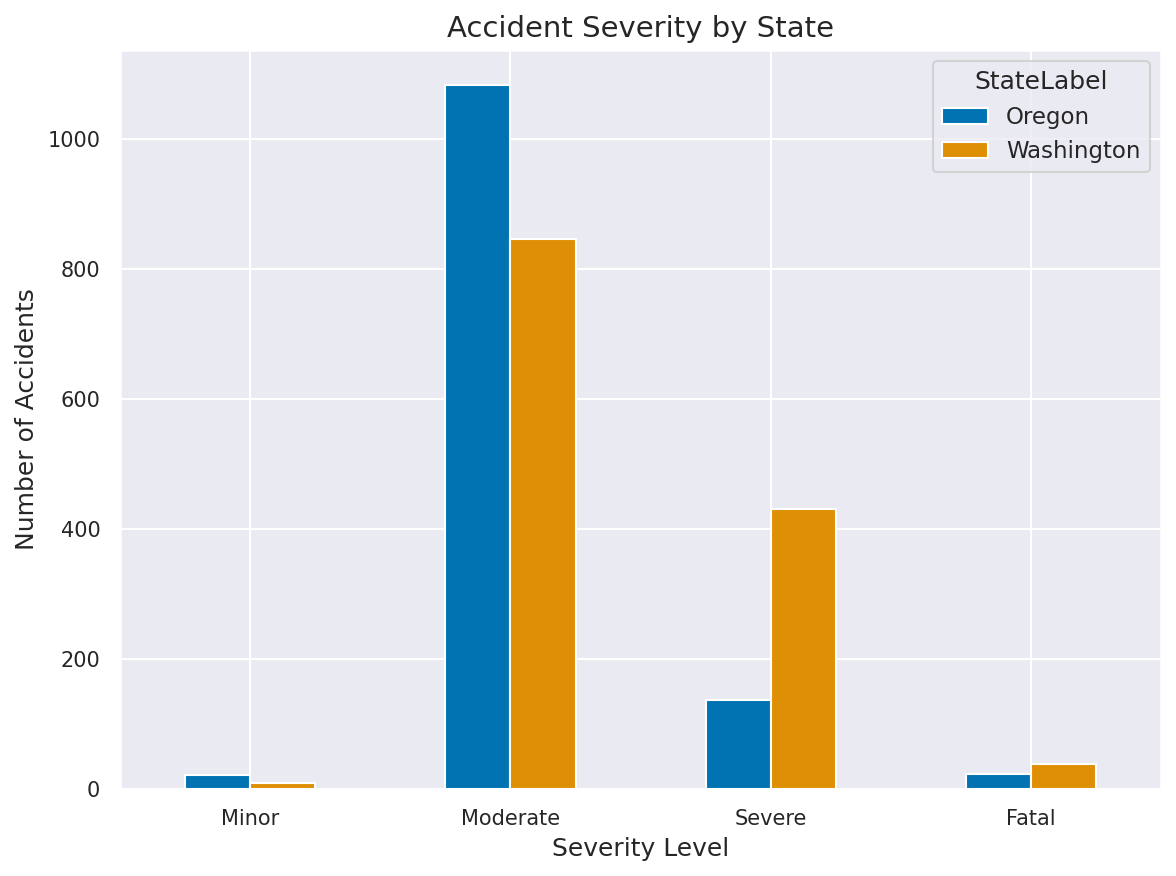

In [19]:
severity_counts = pd.crosstab(accidents["SeverityLabel"],accidents["StateLabel"])
severity_counts = severity_counts.reindex(["Minor", "Moderate", "Severe", "Fatal"])
severity_counts.plot(kind="bar",figsize=(8,6))

plt.title("Accident Severity by State")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Season and Accident Count by State

Both states have relatively similar accident numbers in all seasons except for summer, where Washington significantly outpaces Oregon.

In [20]:
season_labels = {0: "Spring",1: "Summer",2: "Fall",3: "Winter"}

accidents["SeasonLabel"] = accidents["Season"].map(season_labels)

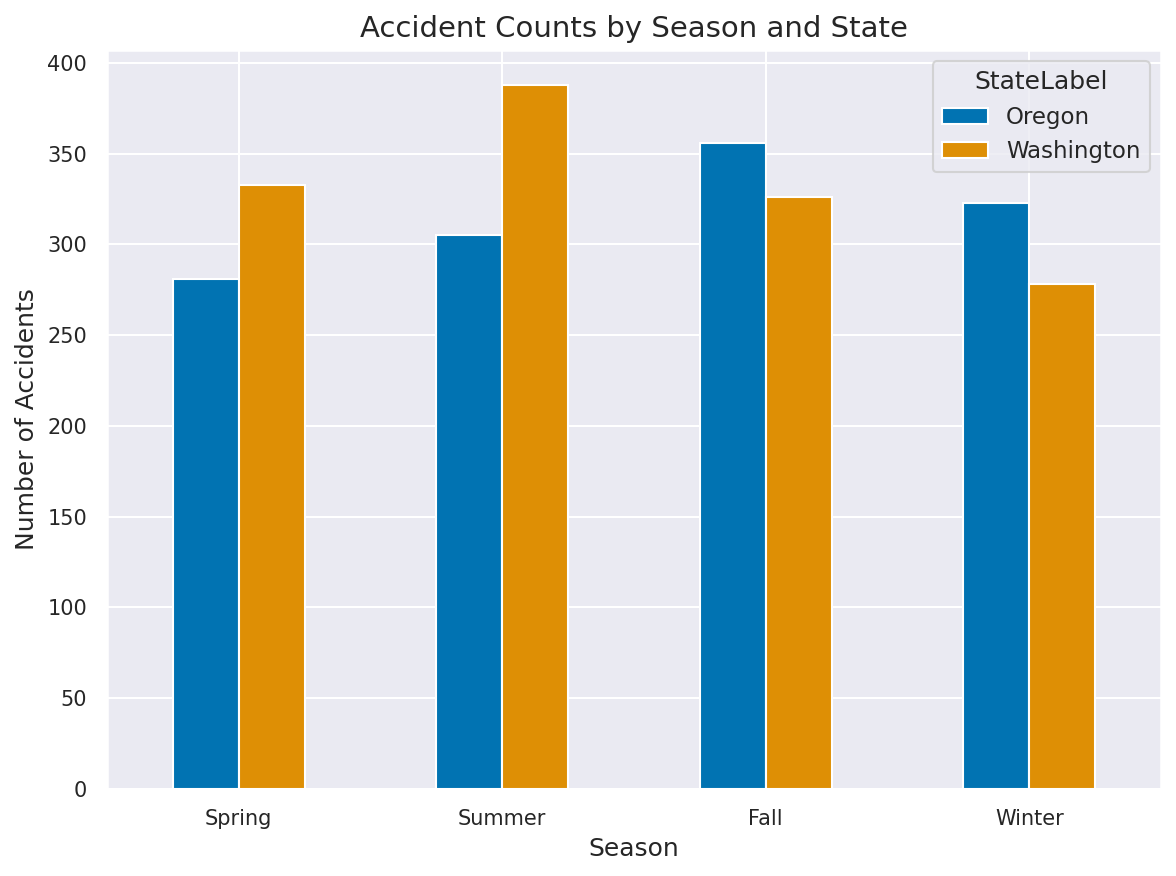

In [21]:
season_counts = pd.crosstab(accidents["SeasonLabel"],accidents["StateLabel"])
season_counts = season_counts.reindex(["Spring", "Summer", "Fall", "Winter"])
season_counts.plot(kind="bar",figsize=(8,6))

plt.title("Accident Counts by Season and State")
plt.xlabel("Season")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Geographical Distribution of Accidents

In [22]:
fig = px.scatter_mapbox(
    accidents,
    lat="StartLat",
    lon="StartLng",
    color="StateLabel",  # Color points by state
    hover_name="StateLabel",
    zoom=4.5,  # Adjust zoom level to focus on OR/WA
    center={"lat": 45.5, "lon": -121},
    mapbox_style="carto-positron",
    title="Accident Locations in Oregon and Washington")

fig.show()

### Summary Statistics

* Weather variables have a large spread, with the exception of Pressure and Visibility.
* Temperature and Pressure are normally distributed. Humidity is right-skewed, Distance and Wind Speed are left-skewed. Outliers are already processed and removed.  


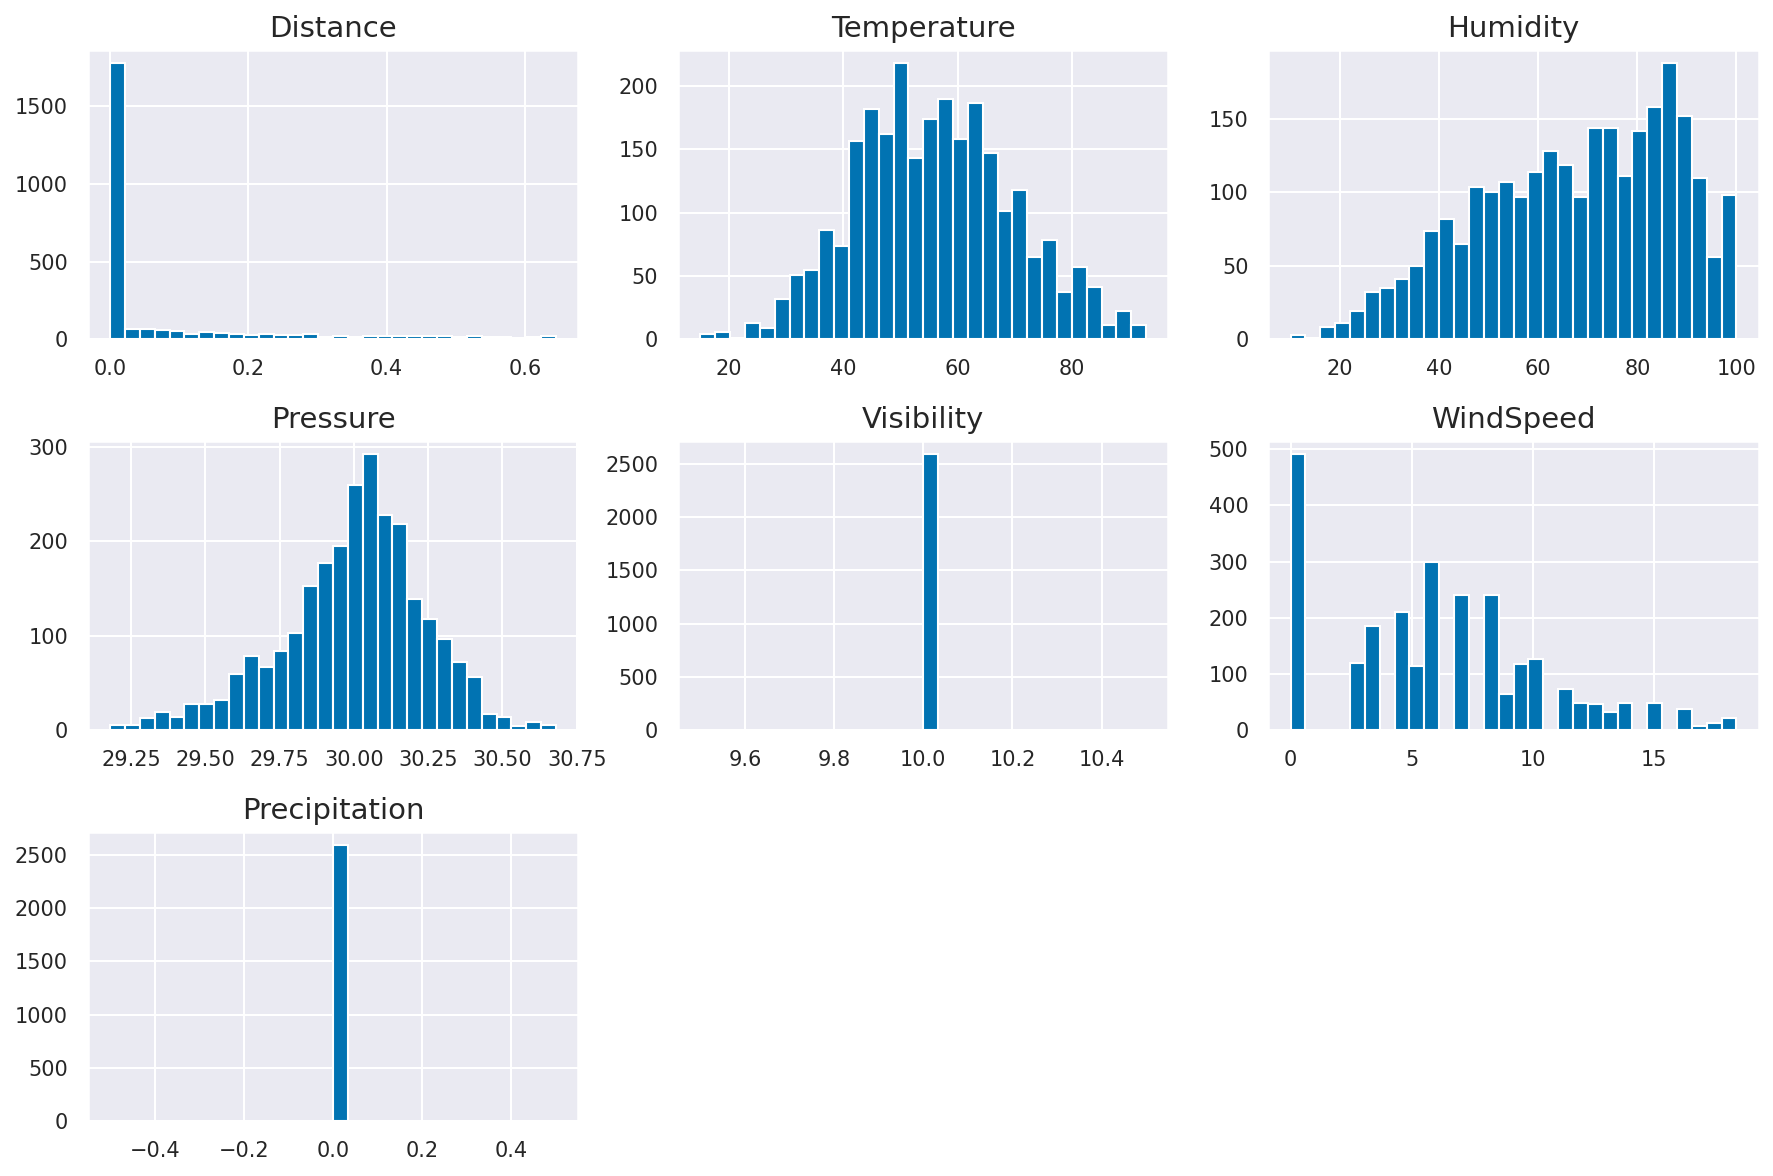

In [23]:
continuous_cols = ["Distance","Temperature","Humidity","Pressure","Visibility","WindSpeed","Precipitation"]
accidents[continuous_cols].hist(figsize=(12,8),bins=30)

plt.tight_layout()
plt.show()

In [24]:
continuous_cols = ["Distance","Temperature","Humidity","Pressure","Visibility","WindSpeed","Precipitation"]

summary_stats = accidents[continuous_cols].describe().T
summary_stats.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Distance,2590.00,0.08,0.15,0.00,0.00,0.00,0.08,0.65
Temperature,2590.00,55.86,13.82,15.00,46.00,55.00,65.00,93.00
Humidity,2590.00,67.07,19.76,10.00,52.00,70.00,83.00,100.00
Pressure,2590.00,29.99,0.24,29.18,29.86,30.02,30.15,30.68
Visibility,2590.00,10.00,0.00,10.00,10.00,10.00,10.00,10.00
WindSpeed,2590.00,6.20,4.38,0.00,3.50,5.80,9.00,18.40
Precipitation,2590.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# Methodology

### Scale the data

In [25]:
# Create X
X = accidents.copy()

# Drop EDA columns
X = X.drop(columns=["SeverityLabel", "StateLabel", "SeasonLabel"])

# -----> State is techincally a categorical variable even though it's stored as an integer so it may be best to drop it
# X = X.drop(columns=["SeverityLabel", "StateLabel", "SeasonLabel", "State"])

In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2590 entries, 100 to 99919
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Severity        2590 non-null   int64  
 1   StartLat        2590 non-null   float64
 2   StartLng        2590 non-null   float64
 3   Distance        2590 non-null   float64
 4   State           2590 non-null   int64  
 5   Temperature     2590 non-null   float64
 6   Humidity        2590 non-null   int64  
 7   Pressure        2590 non-null   float64
 8   Visibility      2590 non-null   float64
 9   WindSpeed       2590 non-null   float64
 10  Precipitation   2590 non-null   float64
 11  Amenity         2590 non-null   int64  
 12  Bump            2590 non-null   int64  
 13  Crossing        2590 non-null   int64  
 14  GiveWay         2590 non-null   int64  
 15  Junction        2590 non-null   int64  
 16  NoExit          2590 non-null   int64  
 17  Railway         2590 non-null   int

In [27]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
# Convert back to df
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

In [29]:
X_scaled.head()

,Severity,StartLat,StartLng,Distance,State,Temperature,Humidity,Pressure,Visibility,WindSpeed,Precipitation,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,Year,Season,Time,Duration
0,-0.4987,-2.1275,4.8328,-0.5187,-1.0234,0.8784,-1.3701,-0.2232,0.0000,-0.0905,0.0000,-0.2600,-0.0197,-0.4024,-0.0557,-0.2471,-0.0653,-0.1592,-0.0197,-0.2575,-0.1679,-0.0440,-0.3933,-0.2221,-0.4499,-1.2179,-0.6610
1,3.4094,0.9040,0.0539,-0.5187,0.9771,-0.1349,-0.2565,0.6924,0.0000,-0.3643,0.0000,-0.2600,-0.0197,2.4849,-0.0557,-0.2471,-0.0653,-0.1592,-0.0197,-0.2575,-0.1679,-0.0440,2.5424,-0.2221,-1.3673,0.8211,1.7197
2,-0.4987,-0.5029,-0.1749,-0.4328,-1.0234,0.8061,-0.0541,0.4427,0.0000,-0.0449,0.0000,-0.2600,-0.0197,2.4849,-0.0557,-0.2471,-0.0653,-0.1592,-0.0197,-0.2575,-0.1679,-0.0440,2.5424,0.6470,0.4676,0.8211,0.8128
3,-0.4987,0.8537,0.0844,-0.5187,0.9771,-0.4244,0.6546,-0.7226,0.0000,0.1832,0.0000,-0.2600,-0.0197,-0.4024,-0.0557,-0.2471,-0.0653,-0.1592,-0.0197,-0.2575,-0.1679,-0.0440,-0.3933,0.6470,0.4676,-1.2179,-0.1017
4,-0.4987,-0.3963,-0.2754,-0.5187,-1.0234,-0.4244,-0.5096,1.0670,0.0000,1.3238,0.0000,-0.2600,-0.0197,-0.4024,-0.0557,-0.2471,-0.0653,-0.1592,-0.0197,-0.2575,-0.1679,-0.0440,-0.3933,1.5161,1.3850,0.8211,0.8128


## Principal Component Analysis

* 5 components are meaningfully different from random noise, based on the scree plot.
* Cumulative variance curve doesn't flatten until around 20 components. This shows that information is spread across many variables where no single dominant factor exists.
* The variables contain many distinct pieces of information that cannot be compressed into only a few dimensions.
* PC1 was driven by latitude, state, traffic signals, and crossings. This suggests that the component distinguishes accidents occurring in different geographic regions and roadway environments, particularly separating more urban Washington locations from accidents occurring elsewhere.
* PC2 was associated with humidity, temperature, season, and time of day. Positive scores corresponded to cooler, more humid conditions, while negative scores corresponded to warmer and drier conditions. This suggests that the second principal component captures seasonal and weather-related variation in accident conditions.
* The first two principal components do not reveal clearly separated clusters. Instead, the observations form a cloud, suggesting that variation in accident characteristics is spread across many dimensions rather than concentrated into a small number of distinct groups. This is typical in transporation datasets.
* A scatterplot of two original variables only reflects variation in those specific variables. The principal component plot summarizes information from all variables simultaneously.

In [30]:
# Fit the PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [31]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[1.19381444e-01 9.15813398e-02 8.03255493e-02 5.82733434e-02
 5.35932497e-02 4.65964043e-02 4.34054130e-02 4.30384445e-02
 4.12072168e-02 4.07422342e-02 3.94436948e-02 3.80125756e-02
 3.63234115e-02 3.51973449e-02 3.25683458e-02 3.10519567e-02
 2.70093048e-02 2.63058124e-02 2.55981118e-02 2.29903987e-02
 2.18058455e-02 1.88434428e-02 1.24439576e-02 9.49213437e-03
 4.76902382e-03 8.04080268e-18 0.00000000e+00]


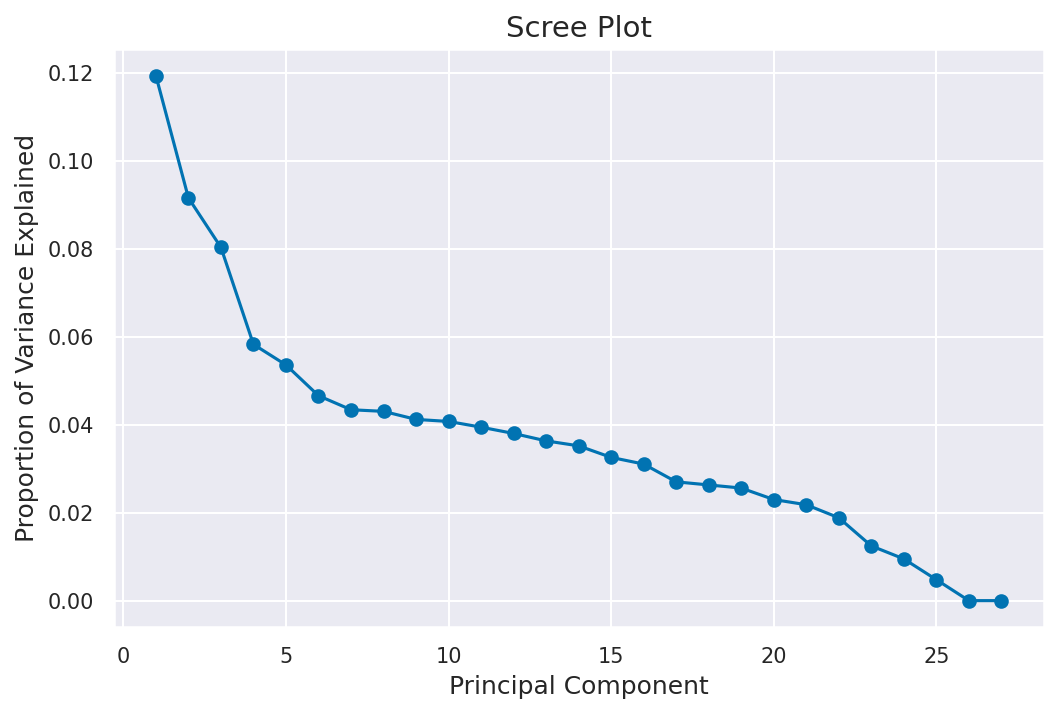

In [32]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1),explained_variance,marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot")
plt.show()


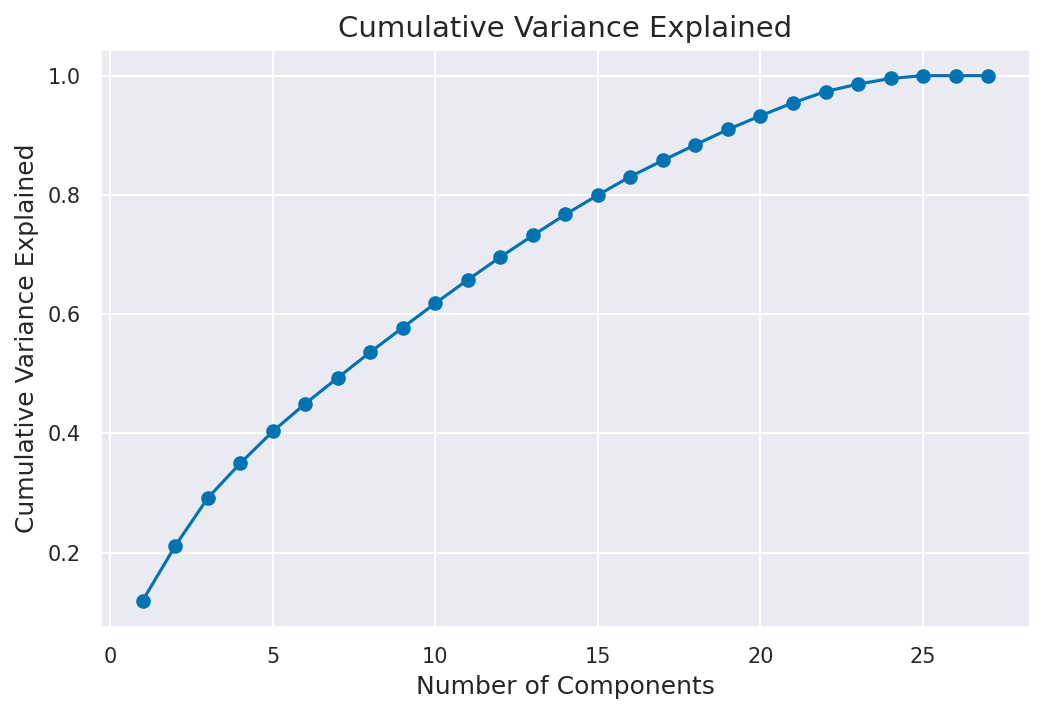

In [33]:
cum_var = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1),cum_var,marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Variance Explained")
plt.show()

In [34]:
pca2 = PCA(n_components=2)

pc_scores = pca2.fit_transform(X_scaled)

In [35]:
pca_df = pd.DataFrame(pc_scores,columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-0.4019,-0.8516
1,2.2586,-0.4063
2,0.5486,-1.7469
3,0.1831,1.2866
4,-1.5111,-0.4844


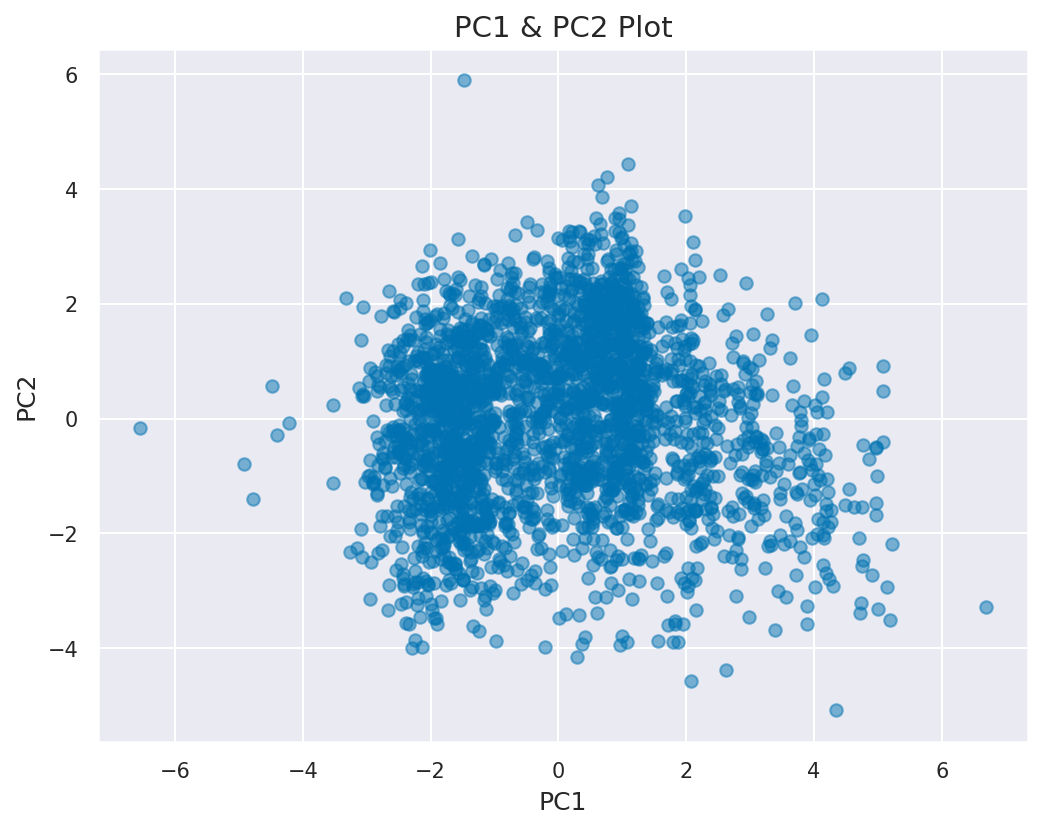

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"],pca_df["PC2"],alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 & PC2 Plot")
plt.show()

In [37]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}"
        for i in range(len(X.columns))],
    index=X.columns)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27
Severity,0.0528,0.1862,-0.3384,-0.0633,-0.0188,-0.0672,0.1605,-0.3120,-0.0765,0.1454,0.1631,-0.1820,0.1036,-0.1531,0.4333,0.1526,0.5466,0.1671,0.0335,0.1498,0.1673,-0.0686,-0.0247,0.0236,-0.0026,-0.0000,-0.0000
StartLat,0.4294,0.1418,-0.2962,-0.0200,-0.0425,-0.1056,0.0353,0.0752,0.0533,0.0881,0.0036,0.1382,0.0867,-0.0306,-0.0493,-0.0950,-0.2496,-0.0324,0.1704,0.1045,-0.0248,-0.2710,0.0130,0.0834,-0.6733,-0.0000,0.0000
StartLng,0.1968,0.0546,-0.1900,0.0092,0.1907,-0.0347,0.0520,0.3336,0.2865,-0.4186,-0.0939,0.1454,-0.1057,0.4738,0.0565,0.0429,0.2467,0.2859,0.0155,0.0417,0.0549,0.1941,0.0292,0.2301,0.0597,0.0000,-0.0000
Distance,-0.2244,-0.0087,-0.0772,-0.0053,0.4465,-0.3103,-0.0222,0.1280,0.1291,0.1594,0.0264,0.1889,0.2815,-0.1584,0.1421,0.0694,0.0168,0.0136,0.3105,-0.5446,-0.1559,0.0695,-0.0017,-0.0116,-0.0206,0.0000,-0.0000
State,0.4223,0.1746,-0.3150,-0.0294,-0.0447,-0.0833,0.0377,0.0600,0.0488,0.1009,0.0087,0.1388,0.1218,-0.0861,-0.0572,-0.1166,-0.2237,-0.0693,0.0705,0.0401,-0.0362,-0.1422,-0.0080,-0.1644,0.7043,0.0000,-0.0000


In [38]:
loadings["PC1"].sort_values(key=abs,ascending=False)

,PC1
StartLat,0.4294
State,0.4223
TrafficSignal,0.3261
Crossing,0.3228
Duration,-0.3101
Amenity,0.2570
Year,-0.2554
Station,0.2275
Distance,-0.2244
StartLng,0.1968


In [39]:
loadings["PC2"].sort_values(key=abs,ascending=False)

,PC2
Humidity,0.5105
Temperature,-0.4991
Time,-0.3668
Season,0.2696
WindSpeed,-0.2095
Severity,0.1862
Crossing,-0.1754
State,0.1746
Pressure,0.1663
Year,-0.1489


In [40]:
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

pca_summary = pca_summary.round(4)

pca_summary

,PC,Explained Variance,Cumulative Variance
0,PC1,0.1194,0.1194
1,PC2,0.0916,0.2110
2,PC3,0.0803,0.2913
3,PC4,0.0583,0.3496
4,PC5,0.0536,0.4032
5,PC6,0.0466,0.4498
6,PC7,0.0434,0.4932
7,PC8,0.0430,0.5362
8,PC9,0.0412,0.5774
9,PC10,0.0407,0.6181


## Singular Value Decomposition
* The SVD results are similar to those obtained from PCA, which is expected because PCA is computed using SVD. Both methods identified geography and roadway infrastructure as one major source of variation and weather-related conditions as another major source of variation in the accident data.
* The scree plot shows two elbows; the first one at 5 components and the second one at 20 components. The presence of two elbows indicates that the dataset contains both strong global patterns and weaker secondary patterns that require additional components to capture.

**Interpretation of U Matrixx**
* The U matrix contains coordinates for each accident in the lower-dimensional latent space.
* Each row of U represents an accident, while each column represents its position.
* Accidents with similar values in U show similar overall patterns across weather conditions, roadway characteristics, and geographic variables.

**Interpretation of VT Matrix**
* The VT matrix describes how the original variables contribute to each latent dimension.
* Large positive or negative values indicate variables that strongly influence a particular singular component.
* E.g. the first singular vector was driven by latitude, state, traffic signals, and crossings. The second singular vector was associated with humidity, temperature, season, and time of day.


In [41]:
U, S, VT = np.linalg.svd(X_scaled,full_matrices=False)

In [42]:
# ----> This was not defined before so the plot through an error

svd_var = (S ** 2) / np.sum(S ** 2)
svd_cum_var = np.cumsum(svd_var)

svd_summary = pd.DataFrame({
    "Singular Component": [f"SV{i+1}" for i in range(len(svd_var))],
    "Explained Variance": svd_var,
    "Cumulative Variance": svd_cum_var
})

svd_summary

,Singular Component,Explained Variance,Cumulative Variance
0,SV1,0.1194,0.1194
1,SV2,0.0916,0.2110
2,SV3,0.0803,0.2913
3,SV4,0.0583,0.3496
4,SV5,0.0536,0.4032
5,SV6,0.0466,0.4498
6,SV7,0.0434,0.4932
7,SV8,0.0430,0.5362
8,SV9,0.0412,0.5774
9,SV10,0.0407,0.6181


In [43]:
print(U.shape)
print(S.shape)
print(VT.shape)

(2590, 27)
(27,)
(27, 27)


In [44]:
print(S)

[8.79201257e+01 7.70057904e+01 7.21185088e+01 6.14263704e+01
 5.89080887e+01 5.49282912e+01 5.30141537e+01 5.27895755e+01
 5.16543056e+01 5.13620450e+01 5.05369097e+01 4.96116344e+01
 4.84968133e+01 4.77391672e+01 4.59216767e+01 4.48398728e+01
 4.18192836e+01 4.12710716e+01 4.07121326e+01 3.85827464e+01
 3.75756370e+01 3.49301148e+01 2.83856699e+01 2.47914441e+01
 1.75725437e+01 3.90443791e-14 6.50567065e-15]


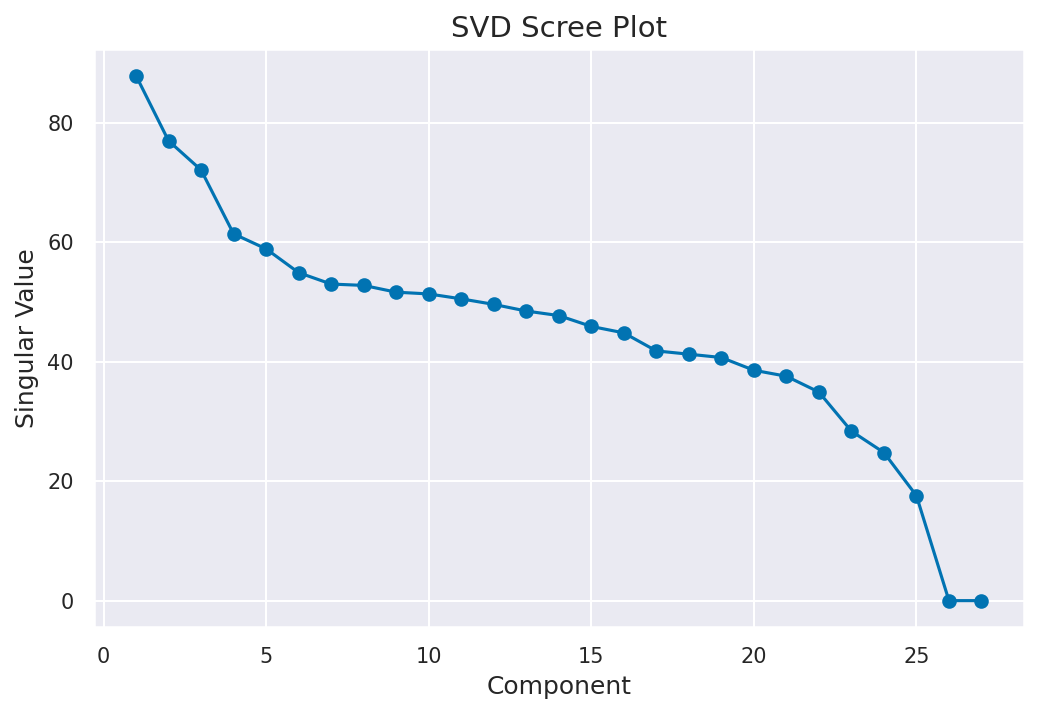

In [45]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(S)+1),S,marker="o")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.title("SVD Scree Plot")
plt.show()

In [46]:
svd_loadings = pd.DataFrame(VT.T,columns=[f"SV{i+1}" for i in range(VT.shape[0])],index=X.columns)

In [47]:
svd_loadings["SV1"].sort_values(key=abs,ascending=False)

,SV1
StartLat,-0.4294
State,-0.4223
TrafficSignal,-0.3261
Crossing,-0.3228
Duration,0.3101
Amenity,-0.2570
Year,0.2554
Station,-0.2275
Distance,0.2244
StartLng,-0.1968


In [48]:
svd_loadings["SV2"].sort_values(key=abs,ascending=False)

,SV2
Humidity,0.5105
Temperature,-0.4991
Time,-0.3668
Season,0.2696
WindSpeed,-0.2095
Severity,0.1862
Crossing,-0.1754
State,0.1746
Pressure,0.1663
Year,-0.1489


In [49]:
U_df = pd.DataFrame(U[:, :2],columns=["SV1", "SV2"])

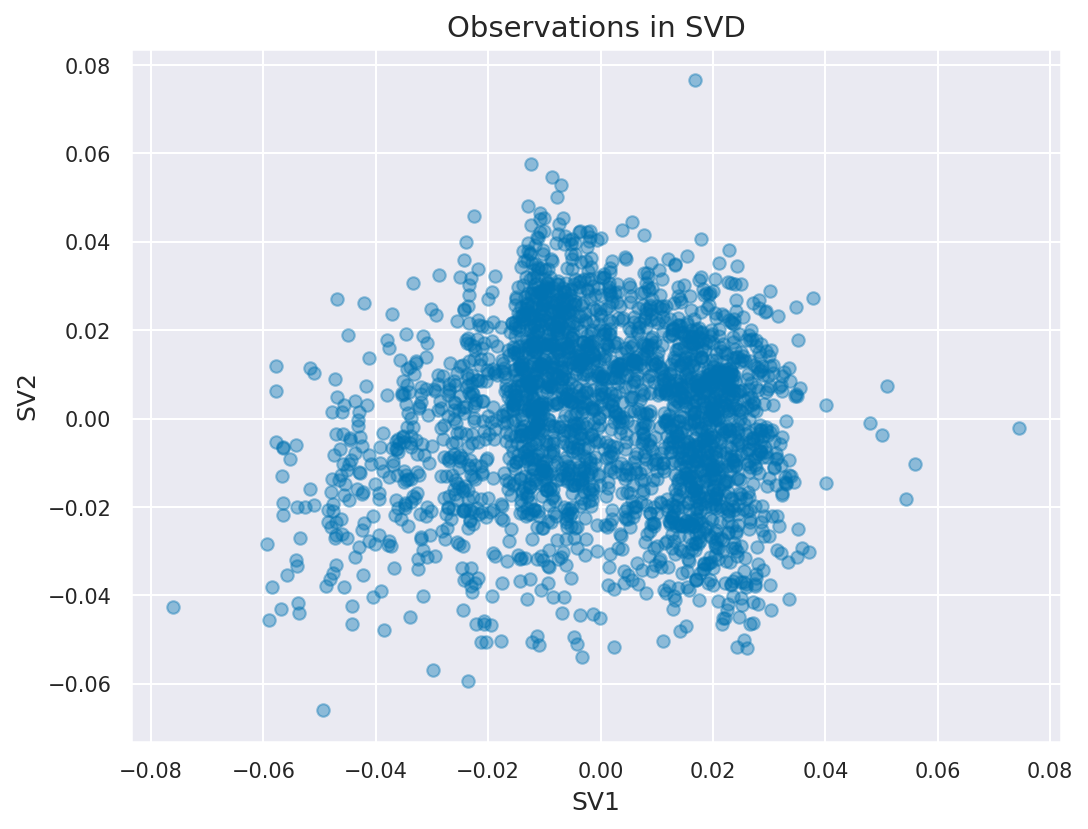

In [50]:
plt.figure(figsize=(8,6))
plt.scatter(U_df["SV1"],U_df["SV2"],alpha=0.4)
plt.xlabel("SV1")
plt.ylabel("SV2")
plt.title("Observations in SVD")
plt.show()

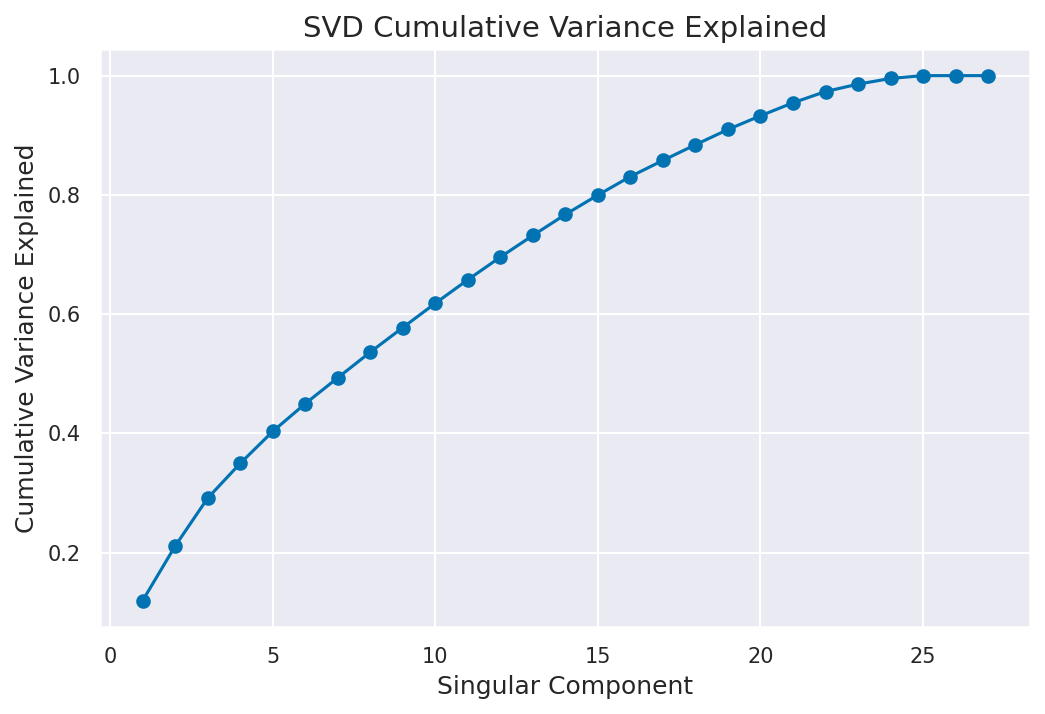

In [51]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(svd_cum_var)+1),svd_cum_var,marker="o")
plt.xlabel("Singular Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("SVD Cumulative Variance Explained")

plt.show()

## Matrix Completion

Since the dataset has no missing values (hehe), we will have to randomly hide some values, use SVD to reconstruct, and then compare reconstruction and actual values. Matrix completion attempts to recover missing entries by exploiting low-rank structure in the data.

The low reconstruction error (0.843) suggests that the our dataset possesses meaningful low-dimensional structure that can be used to recover missing observations.

In [52]:
X_complete = X_scaled.copy()

Create the missing data (10%)

In [53]:
np.random.seed(42)

missing_fraction = 0.10
X_missing = X_complete.copy()

In [54]:
mask = np.random.rand(*X_missing.shape) < missing_fraction

In [55]:
X_missing[mask] = np.nan

Initial mean imputation

In [56]:
imputer = SimpleImputer(strategy="mean")
X_filled = imputer.fit_transform(X_missing)


Matrix completion

In [57]:
rank = 5

In [58]:
U, S, VT = np.linalg.svd(X_filled,full_matrices=False)

In [59]:
U_k = U[:, :rank]
S_k = np.diag(S[:rank])
VT_k = VT[:rank, :]

In [60]:
X_reconstructed = U_k @ S_k @ VT_k

Evaluate missing add-ins

In [61]:
# ----> This was not defined so an error as being thrown
X_complete_np = X_complete.to_numpy()

true_values = X_complete_np[mask]
pred_values = X_reconstructed[mask]

print(true_values.shape)
print(pred_values.shape)

(7021,)
(7021,)


In [62]:
rmse = np.sqrt(mean_squared_error(true_values,pred_values))
print("RMSE:", rmse)

RMSE: 0.7619056144660208


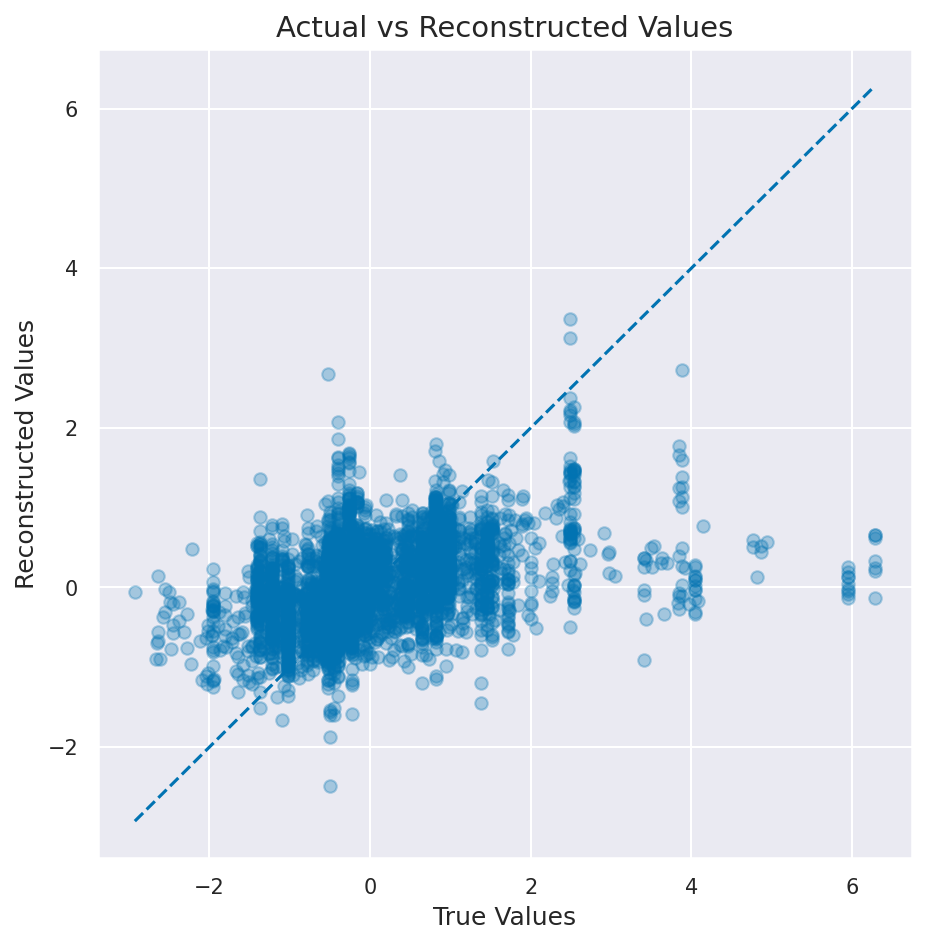

In [63]:
plt.figure(figsize=(7,7))
plt.scatter(true_values,pred_values,alpha=0.3)
min_val = min(true_values.min(), pred_values.min())
max_val = max(true_values.max(), pred_values.max())
plt.plot([min_val, max_val],[min_val, max_val],linestyle="--")
plt.xlabel("True Values")
plt.ylabel("Reconstructed Values")
plt.title("Actual vs Reconstructed Values")
plt.show()

## K-Means Clustering
* The data does not contain strongly separated clusters.
* K-means identified eight clusters based on the silhouette criterion
* However, the clusters show significant overlap. This suggests that accident observations do not form strongly separated groups in low-dimensional space.


In [64]:
X = X_scaled.copy()

In [65]:
# Elbow method
inertia = []

K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=20)
    km.fit(X)
    inertia.append(km.inertia_)

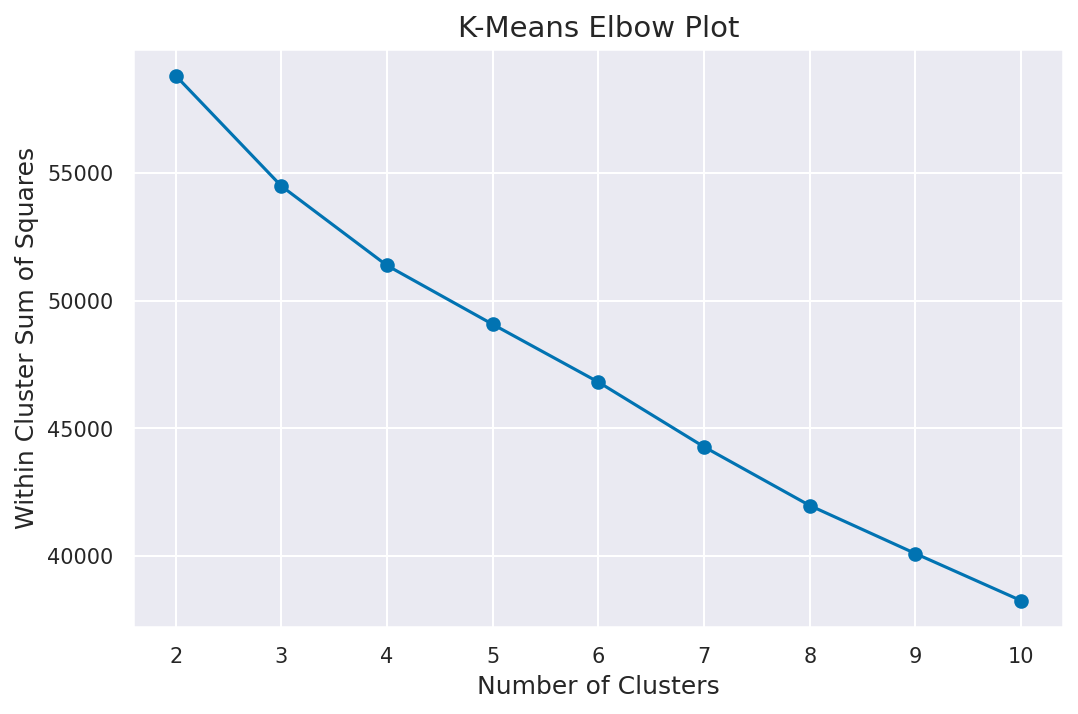

In [66]:
plt.figure(figsize=(8,5))
plt.plot(K_range,inertia,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Within Cluster Sum of Squares")
plt.title("K-Means Elbow Plot")
plt.show()

In [67]:
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=20)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

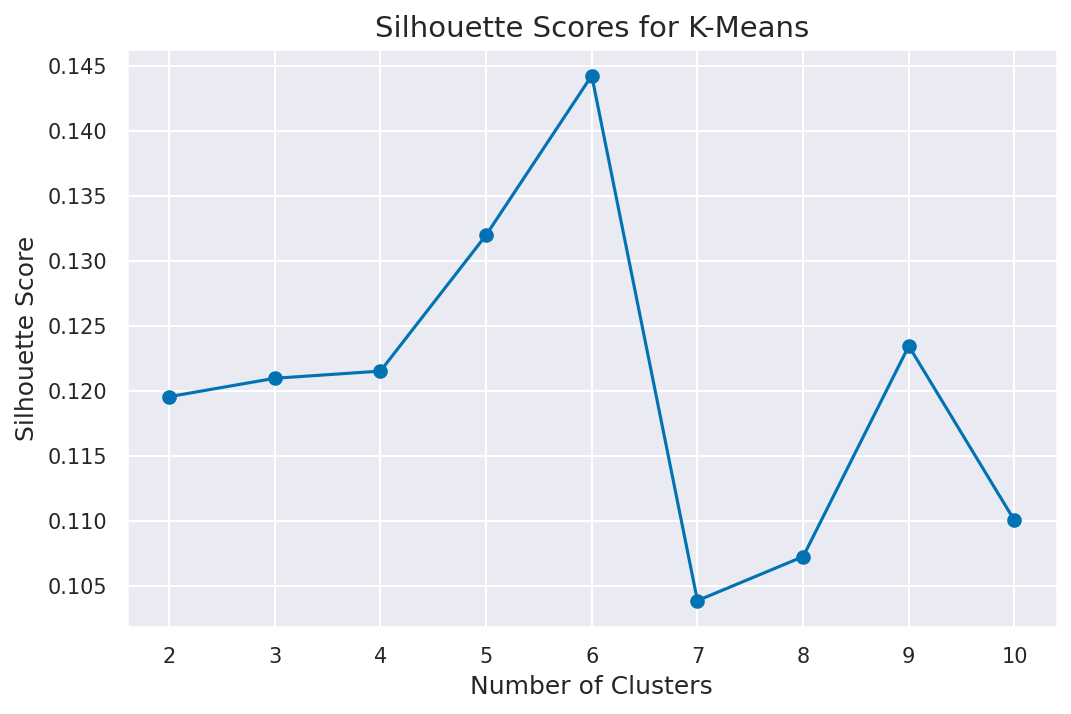

In [68]:
plt.figure(figsize=(8,5))
plt.plot(K_range,sil_scores,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.show()

In [69]:
best_k = 8

In [70]:
kmeans = KMeans(n_clusters=best_k,random_state=42,n_init=20)
cluster_labels = kmeans.fit_predict(X)

In [71]:
accidents["KMeansCluster"] = cluster_labels

In [72]:
pca_df["Cluster"] = cluster_labels

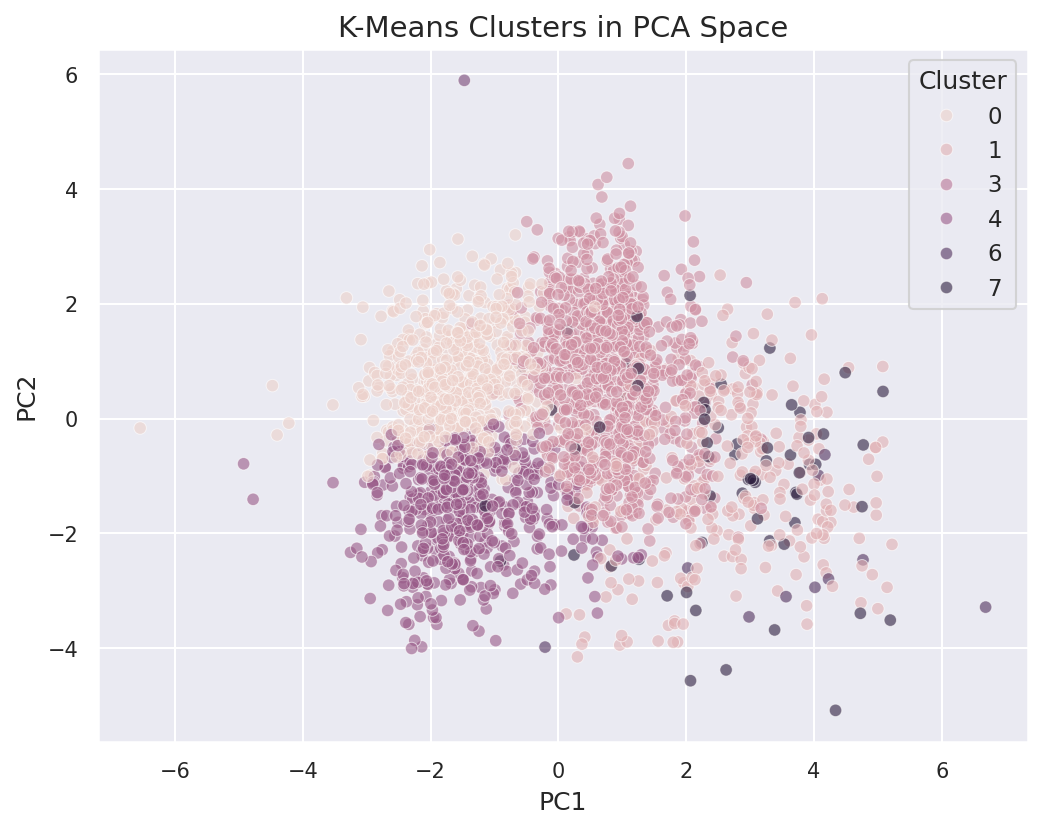

In [73]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",alpha=0.6)
plt.title("K-Means Clusters in PCA Space")
plt.show()

In [74]:
cluster_summary = accidents.groupby("KMeansCluster").mean(numeric_only=True)
cluster_summary.round(2)

,Severity,StartLat,StartLng,Distance,State,Temperature,Humidity,Pressure,Visibility,WindSpeed,Precipitation,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,Year,Season,Time,Duration
KMeansCluster,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2.1600,44.7200,-122.7000,0.0900,0.0100,46.9900,78.6800,30.0200,10.0000,5.1900,0.0000,0.0100,0.0000,0.0200,0.0000,0.0500,0.0000,0.0000,0.0000,0.0100,0.0100,0.0000,0.0200,2018.6500,1.9900,0.3600,184.7100
1,2.0000,46.9500,-122.2500,0.0100,0.7100,57.8400,64.0800,30.0300,10.0000,6.5100,0.0000,0.3700,0.0000,0.8800,0.0200,0.0100,0.0000,0.0000,0.0000,0.3000,0.0800,0.0000,0.8000,2018.0000,1.5100,0.6700,79.2600
2,2.4700,47.5400,-122.1000,0.0600,1.0000,54.9900,70.3500,30.0100,10.0000,5.8800,0.0000,0.0200,0.0000,0.0200,0.0000,0.0600,0.0000,0.0000,0.0000,0.0300,0.0200,0.0000,0.0600,2017.8200,1.4100,0.5600,83.2400
3,2.0000,45.5000,-122.6800,0.0200,0.0000,50.0000,66.0000,30.3500,10.0000,6.9000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,2018.0000,2.0000,1.0000,240.0000
4,2.1200,45.0600,-122.6700,0.1400,0.0800,67.1100,48.5800,29.9100,10.0000,7.8700,0.0000,0.0100,0.0000,0.0100,0.0000,0.0900,0.0000,0.0000,0.0000,0.0200,0.0300,0.0000,0.0100,2018.7700,1.0100,0.9100,197.9000
5,2.0000,44.0900,-123.1500,0.0000,0.0000,25.0000,100.0000,30.4600,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,2017.0000,3.0000,0.0000,45.0000
6,2.1800,46.7800,-122.4200,0.0300,0.7300,63.9300,51.5500,30.0500,10.0000,8.2700,0.0000,0.4500,0.0000,0.4500,0.0000,0.0000,1.0000,0.0900,0.0000,0.5500,0.0000,0.0000,0.3600,2017.6400,1.4500,0.6400,91.5500
7,2.1100,46.6300,-122.3900,0.0500,0.5900,56.8900,66.1600,30.0800,10.0000,5.8600,0.0000,0.1700,0.0000,0.8700,0.0200,0.0300,0.0000,1.0000,0.0000,0.2400,0.0200,0.0000,0.4600,2018.1400,1.4600,0.5700,90.3500


## Hierarchial Clustering

### Single
* This produces an oddly high score.
* This might be due to the chaining effect where it connects clusters by nearest neighbours.

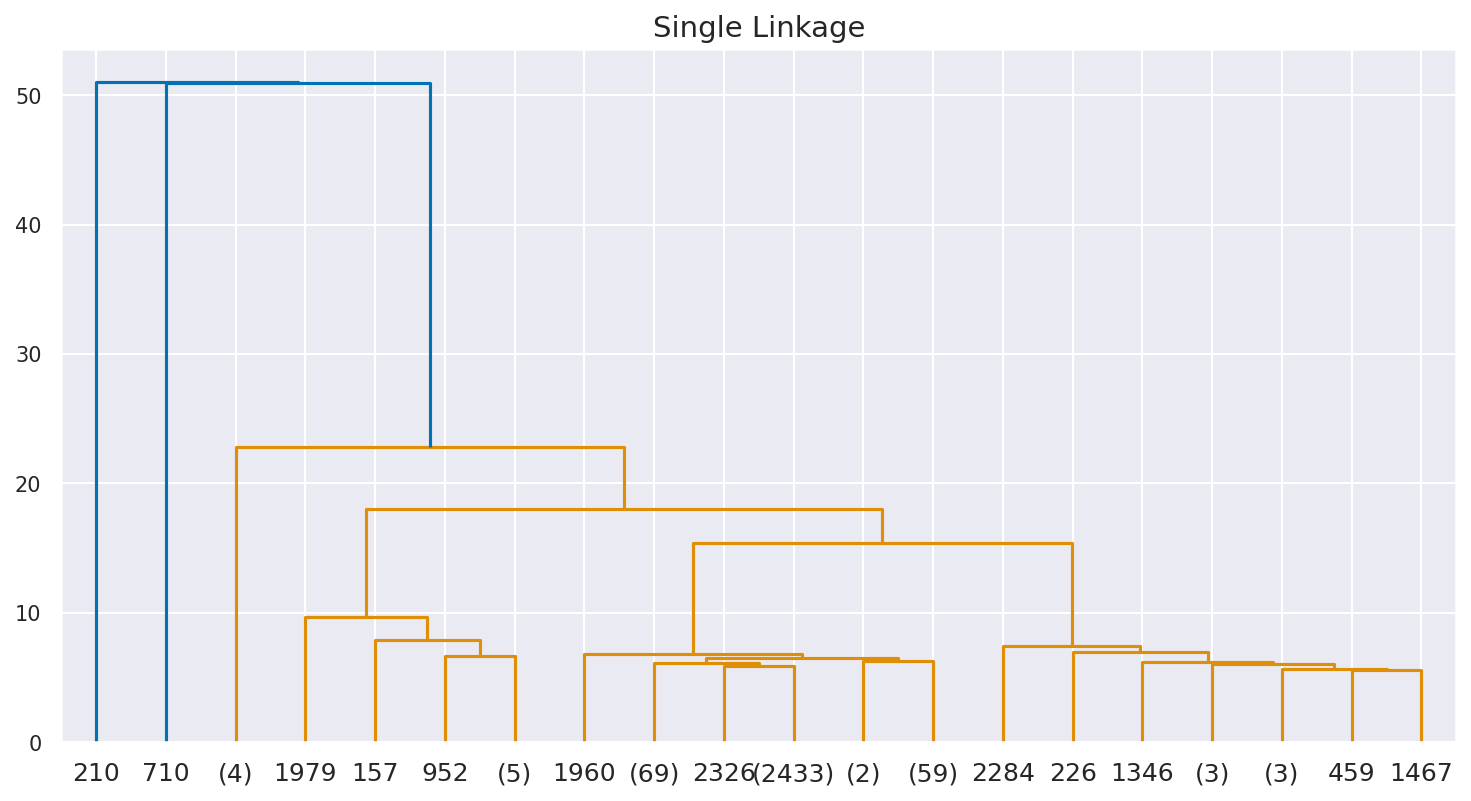

In [75]:
Z_single = linkage(X,method="single")

plt.figure(figsize=(12,6))
dendrogram(Z_single,truncate_mode="lastp",p=20)
plt.title("Single Linkage")
plt.show()

### Complete
* Moderate score suggest some weak structure
* Forces compact clusters

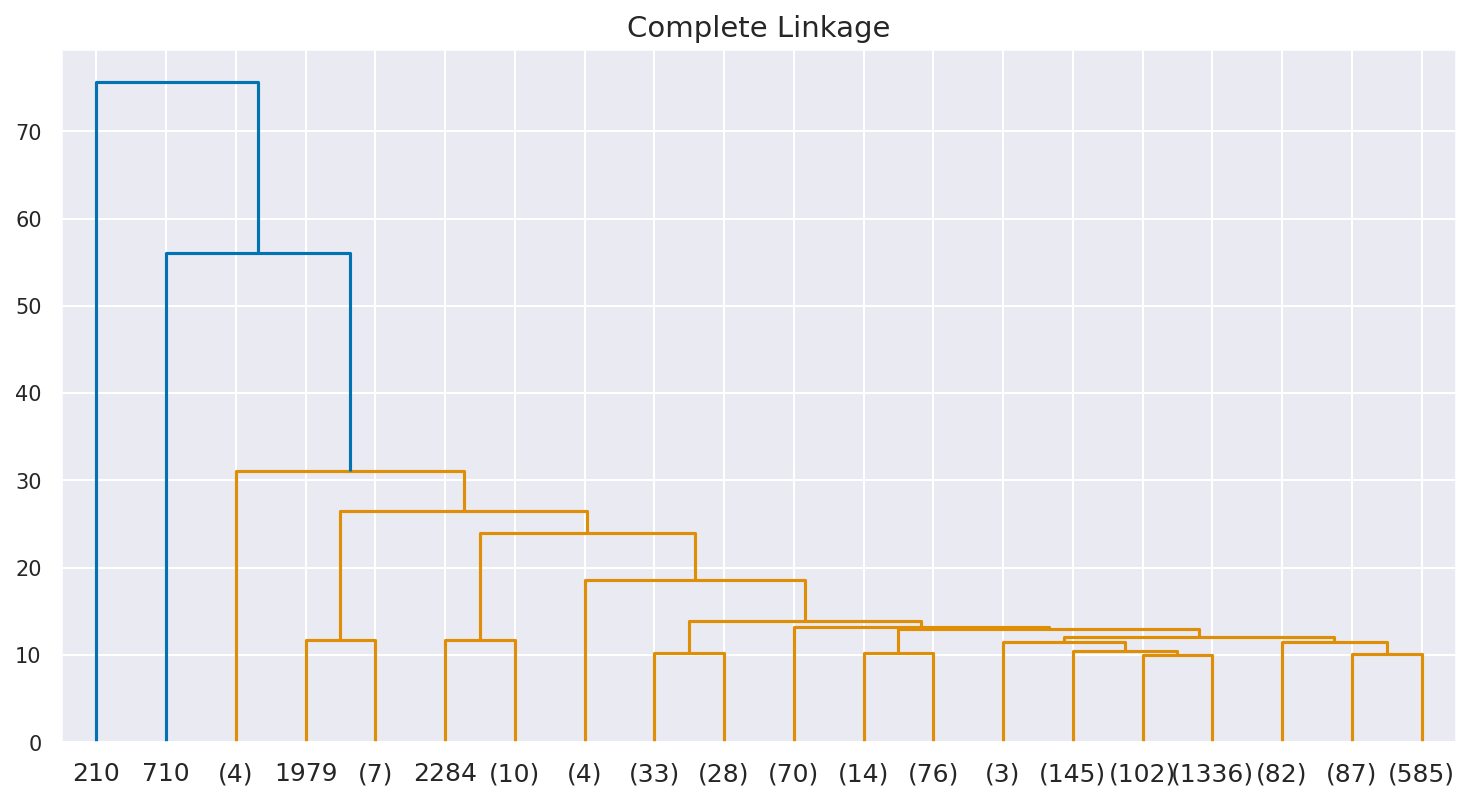

In [76]:
Z_complete = linkage(X,method="complete")

plt.figure(figsize=(12,6))
dendrogram(Z_complete,truncate_mode="lastp",p=20)
plt.title("Complete Linkage")
plt.show()

### Average
* Smoother compromise
* Slightly better than complete

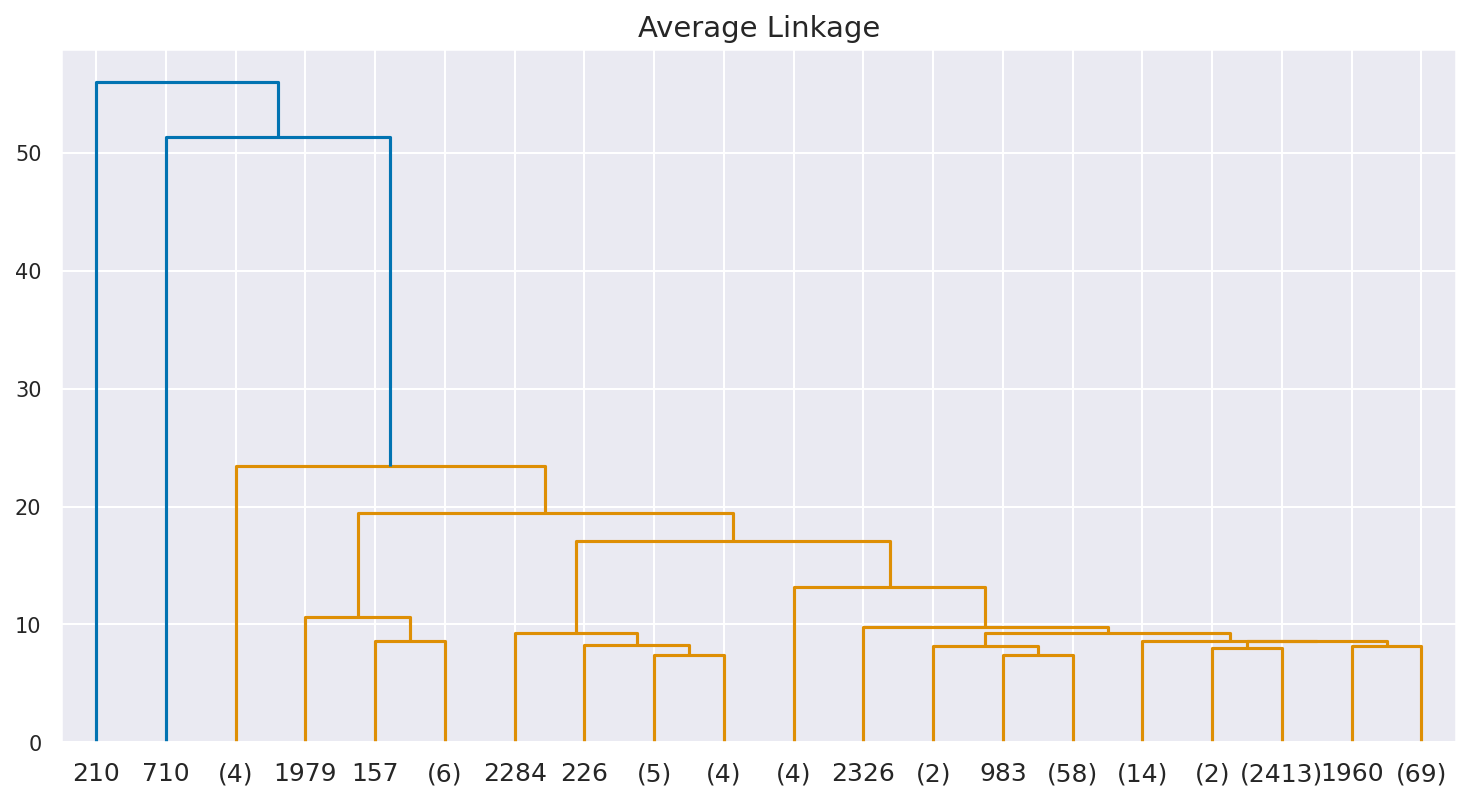

In [77]:
Z_average = linkage(X,method="average")

plt.figure(figsize=(12,6))
dendrogram(Z_average,truncate_mode="lastp",p=20)
plt.title("Average Linkage")
plt.show()

### Ward
* Very low score, there is no strong cluster structure in the data

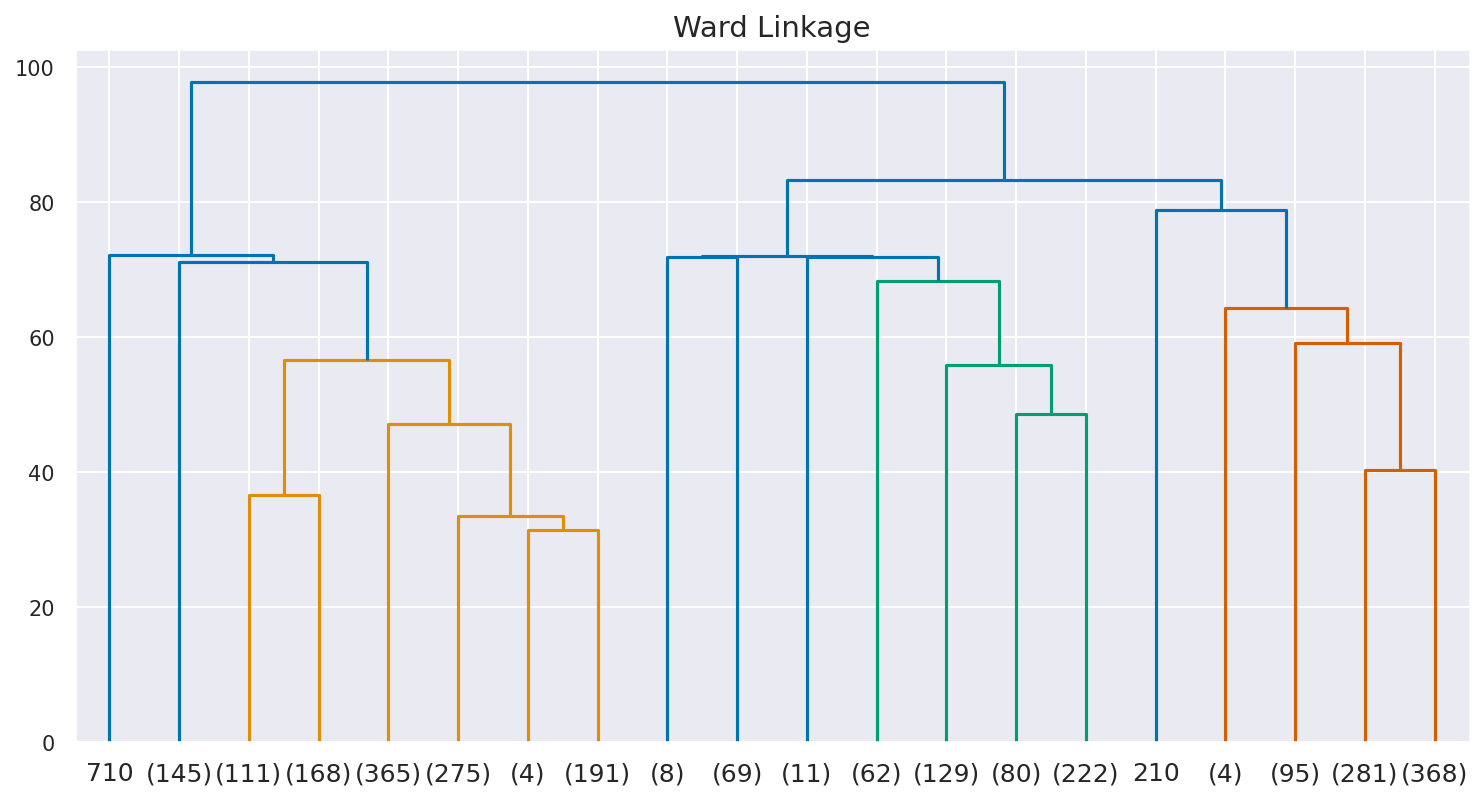

In [78]:
Z_ward = linkage(X,method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z_ward,truncate_mode="lastp",p=20)
plt.title("Ward Linkage")
plt.show()

In [79]:
# Silhouette scores
methods = ["single","complete","average","ward"]

for method in methods:
    model = AgglomerativeClustering(n_clusters=best_k,linkage=method)
    labels = model.fit_predict(X)
    score = silhouette_score(X,labels)

    print(method, score)

single 0.6445496506324383
complete 0.36720272891953976
average 0.5423049478462507
ward 0.1072383777204943


# Final Thoughts

Across PCA, SVD, k-means clustering, and hierarchical clustering, a consistent pattern emerges:
* The data contains moderate low-dimensional structure
* Variation is driven primarily by geography and weather
* However, there is no strong evidence of discrete, well-separated clusters


# References

Dataset: Sobhan Moosavi. (2023). US Accidents (2016 - 2023) [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DS/199387

Interactive visualizations. Plotly. (n.d.). https://dash.plotly.com/interactive-graphing

Gundersen, G. (n.d.). Singular value decomposition as simply as possible. Singular value decomposition. https://gregorygundersen.com/blog/2018/12/10/svd/

Singular value decomposition (SVD). Intermediate Quantitative Economics with Python. (n.d.). https://python.quantecon.org/svd_intro.html

D’Agostino, A. (2025, January 23). Introduction to PCA in python with Sklearn, Pandas, and Matplotlib. Towards Data Science. https://towardsdatascience.com/introduction-to-pca-in-python-with-sklearn-pandas-and-matplotlib-476880f30238/

Quantitative Finance & Algo Trading Blog by QuantInsti. (2026, March 17). Hierarchical clustering in python: A comprehensive implementation guide. Quantitative Finance & Algo Trading Blog by QuantInsti. https://blog.quantinsti.com/hierarchical-clustering-python/


